# Test: geodesic dilation 

This notebook tests geodesic dilation implementation using it to perform Reconstruction by Dilation

## Import libraries

Assures that the harpia module has already been compiled with cython, before (command: python3 setup.py)

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# workaround to allow importing harpia python module
import sys
sys.path.append('../../../')
from harpia.morphology.fill_holes_binary import reconstruction_binary, fill_holes
from harpia.morphology.operations_binary import erosion_binary
from harpia.morphology.operations_grayscale import erosion_grayscale

import harpia.morphology.operations_binary as harpia


In [2]:
def contiguous(array: np.ndarray ) -> np.ndarray:
    if not array.flags['C_CONTIGUOUS']:
        array = np.ascontiguousarray(array.astype(array.type()))

In [3]:
# test if all functions were imported
help(harpia)

Help on module harpia.morphology.operations_binary in harpia.morphology:

NAME
    harpia.morphology.operations_binary

FUNCTIONS
    closing_binary(hostImage, hostOutput, kernel, kernel_xsize, kernel_ysize, kernel_zsize, xsize, ysize, zsize, flag_verbose)
    
    dilation_binary(hostImage, hostOutput, kernel, kernel_xsize, kernel_ysize, kernel_zsize, xsize, ysize, zsize, flag_verbose)
    
    erosion_binary(hostImage, hostOutput, kernel, kernel_xsize, kernel_ysize, kernel_zsize, xsize, ysize, zsize, flag_verbose)
    
    geodesic_dilation_binary(hostImage, hostOutput, hostMask, xsize, ysize, zsize, flag_verbose)
    
    geodesic_erosion_binary(hostImage, hostOutput, hostMask, xsize, ysize, zsize, flag_verbose)
    
    opening_binary(hostImage, hostOutput, kernel, kernel_xsize, kernel_ysize, kernel_zsize, xsize, ysize, zsize, flag_verbose)

DATA
    __test__ = {}

FILE
    /home/camila.araujo/Documents/harpia-model/harpia/morphology/operations_binary.cpython-310-x86_64-linux-gnu.s

## Framework

Useful functions to test harpia module

In [4]:
def get_vertical_line_kernel():
    kernel = np.array([
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0]
    ], dtype=np.int32)

    kernel = kernel.reshape(kernel.shape[0], kernel.shape[1], 1)

    return kernel

def get_horizontal_line_kernel():
    kernel = np.array([
        [1, 1, 1],
        [0, 0, 0],
        [0, 0, 0]
    ], dtype=np.int32)

    kernel = kernel.reshape(kernel.shape[0], kernel.shape[1], 1)

    return kernel

def get_kernel():
    kernel = np.array([
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]
    ], dtype=np.int32)

    kernel = kernel.reshape(kernel.shape[0], kernel.shape[1], 1)

    return kernel


In [5]:
def show(image, output):
    # Plot the original and the processed images
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    axes[1].imshow(output, cmap='gray')
    axes[1].set_title('Processed Image')
    axes[1].axis('off')


## Read Input Image

In [6]:
# Read the raw data from the file
raw_data = np.fromfile('../../../example_images/binary/blobs_355x321x1_16b.raw', dtype=np.uint16)
raw_data = raw_data.astype(np.int32)

# Define the dimensions of the image
xsize = 355  # replace with the actual xsize
ysize = 321  # replace with the actual ysize
zsize = 1

# Check the size of the data
if raw_data.size != xsize * ysize * zsize:
    raise ValueError(f"Expected {xsize * ysize * zsize} elements, but got {raw_data.size} elements.")

# Reshape the data into the correct dimensions
image = raw_data.reshape((ysize, xsize, zsize))

print('input : ',image.shape)

input :  (321, 355, 1)


In [7]:
# Define the kernel (example 3x3 kernel)
kernel = np.array([
    [1, 0, 0],
    [1, 0, 0],
    [1, 0, 0]
], dtype=np.int32)

kernel_reflex = np.array([
    [0, 0, 1],
    [0, 0, 1],
    [0, 0, 1]
], dtype=np.int32)

# Define kernel and image sizes
kernel_xsize = 3
kernel_ysize = 3
kernel_zsize = 1

flag_verbose = 0

kernel = get_kernel()

print('kernel: ',kernel.shape)

kernel:  (3, 3, 1)


## TEST: grayscale == binary?

False

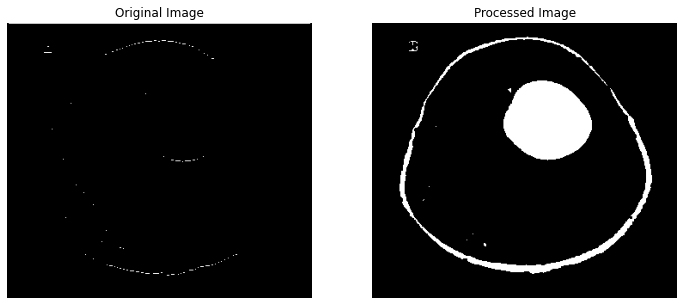

In [8]:
out1 = np.zeros_like(image)
out2 = np.zeros_like(image)
erosion_binary(image, out1, get_horizontal_line_kernel(), kernel_xsize, kernel_ysize, kernel_zsize, xsize, ysize, zsize, flag_verbose)
erosion_grayscale(image, out2, get_horizontal_line_kernel(), kernel_xsize, kernel_ysize, kernel_zsize, xsize, ysize, zsize, flag_verbose)
show(out1, out2)
(out1 == out2).all()

## Reconstruction by Dilation

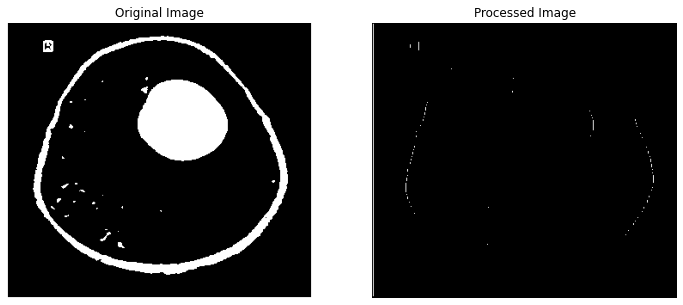

In [9]:
# Obtain the marker image
marker = np.zeros_like(image)
harpia.erosion_binary(image, marker, get_vertical_line_kernel(), kernel_xsize, kernel_ysize, kernel_zsize, xsize, ysize, zsize, flag_verbose)
show(image, marker)

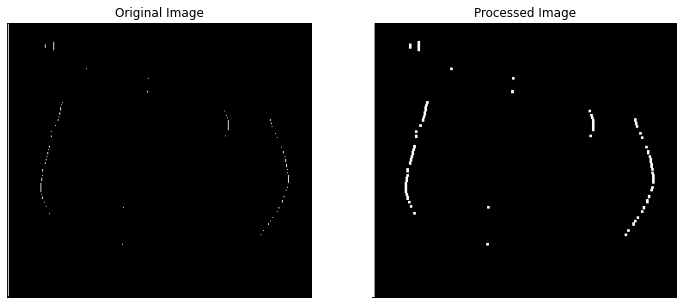

In [10]:
# Dilation
marker_dilated = np.zeros_like(image) #create empty output
harpia.dilation_binary(marker, marker_dilated, kernel, kernel_xsize, kernel_ysize, kernel_zsize, xsize, ysize, zsize, flag_verbose)
show(marker, marker_dilated)

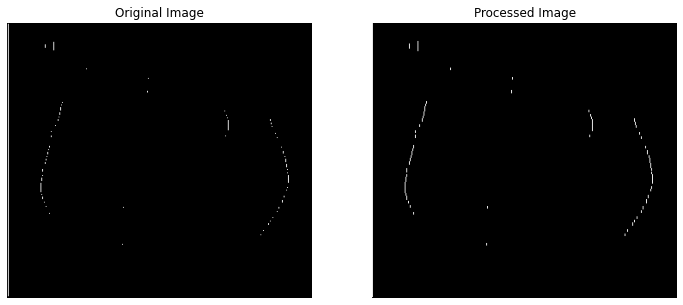

In [11]:
# Geodesic dilation (one step)
marker_geo_dilated = np.zeros_like(image) #create empty output
harpia.geodesic_dilation_binary(marker, marker_geo_dilated, image, xsize, ysize, zsize, flag_verbose)
show(marker, marker_geo_dilated)

GOT IT:  515


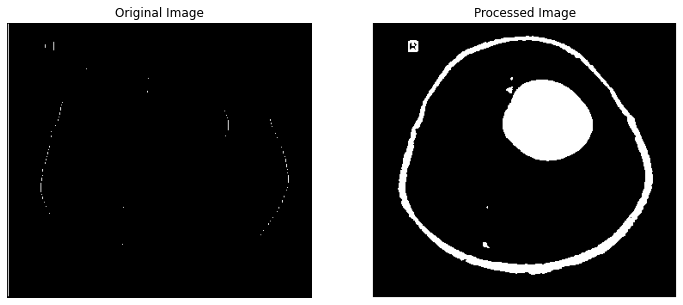

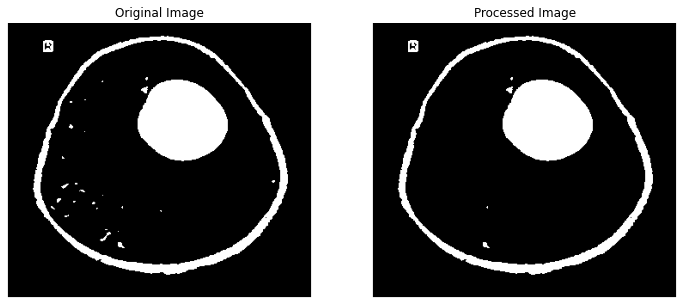

In [12]:
#Reconstruction by dilation to test geodesic dilation correctness

marker_input = marker
output_aux = np.zeros_like(image)
count = 0
for i in range(1000):
    output_aux = np.zeros_like(image)
    harpia.geodesic_dilation_binary(marker_input, output_aux, image, xsize, ysize, zsize, flag_verbose)
    count +=1
    if((marker_input == output_aux).all()):
        print('GOT IT: ', count)
        break
    else:
        marker_input = output_aux
output = marker_input
show(marker, output)
show(image, output)


## Reconstruction complete

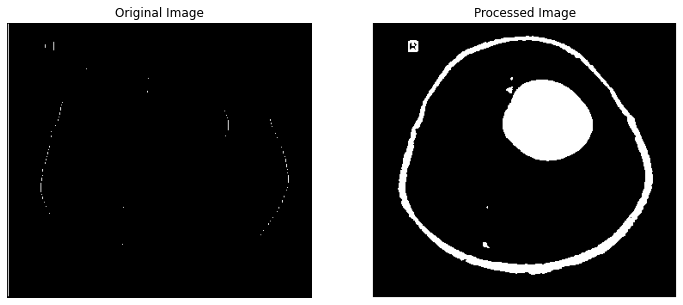

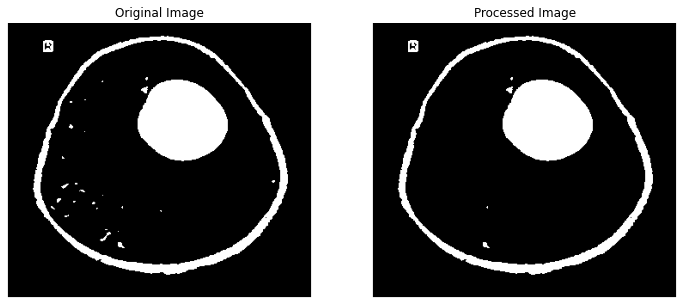

In [13]:
#Reconstruction by dilation complete

marker_input = marker
output_aux = np.zeros_like(image)

output_aux = np.zeros_like(image)
reconstruction_binary(marker_input, output_aux, image,
                      xsize, ysize, zsize, 1, flag_verbose)

output = marker_input
show(marker, output_aux)
show(image, output_aux)

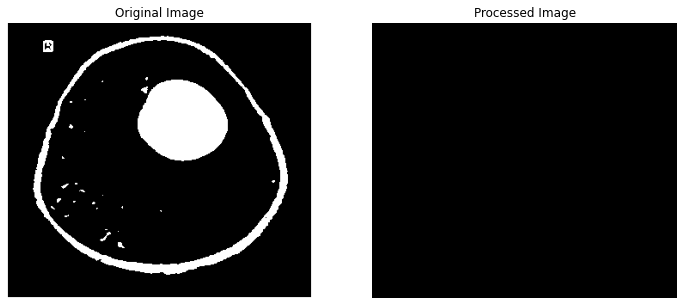

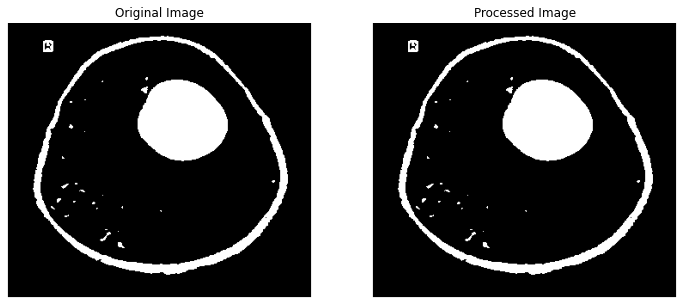

In [23]:
#Fill Holes
output_aux = np.zeros_like(image)
show(image, output_aux)
fill_holes(image, output_aux, xsize, ysize, zsize, flag_verbose)

show(image, output_aux)

In [17]:
(image == output_aux).all()

True